# Pythia Attention Sinks — Stable FP32 + Better Visualizations

This notebook visualizes **attention sinks** in `EleutherAI/pythia-160m`.

### Improvements over the previous notebook

- Forces the model to run in **FP32**, avoiding the FP16 attention overflow that produced `NaN`.
- Uses Hugging Face's **eager attention** so attention probabilities are returned explicitly.
- Disables mixed-precision autocast during the forward pass.
- Checks **every layer** for `NaN` / `Inf` before doing any averaging.
- Computes both raw cumulative attention and **causal-opportunity-normalized attention**.
- Measures sink strength separately for **every layer and every attention head**.
- Includes clearer visualizations:
  - global attention heatmap
  - attention received by token position
  - normalized attention received
  - layer × head sink-score heatmap
  - first-token attention by layer/head
  - strongest sink-head attention matrix
  - attention-to-sink across query positions
  - top attended positions with token labels

> Important: We deliberately do **not** use `torch.nan_to_num()`, because replacing invalid attention values with zeros would corrupt the experiment.

## 1. Install dependencies

In [1]:
!pip -q install -U transformers accelerate matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 39.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
dask-cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.


## 2. Imports and reproducibility

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

MODEL_NAME = "EleutherAI/pythia-160m"
MAX_TOKENS = 192
SINK_K = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Keep float32 math as precise as practical.
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = False

try:
    torch.set_float32_matmul_precision("highest")
except Exception:
    pass

print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.11.0+cu130


## 3. Load Pythia in FP32

This is the main numerical-stability fix.

The previous notebook used FP16 on GPU:

```python
torch_dtype=torch.float16
```

For attention inspection we instead use:

```python
torch_dtype=torch.float32
```

Pythia-160M is small enough that this is practical on Colab/Kaggle GPUs.

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32,
    attn_implementation="eager",
)

model = model.to(device)
model.eval()


first_param = next(model.parameters())

print("Loaded:", MODEL_NAME)
print("Parameter dtype:", first_param.dtype)
print("Layers:", model.config.num_hidden_layers)
print("Attention heads:", model.config.num_attention_heads)
print("Hidden size:", model.config.hidden_size)

assert first_param.dtype == torch.float32, "Model is not FP32."

config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded: EleutherAI/pythia-160m
Parameter dtype: torch.float32
Layers: 12
Attention heads: 12
Hidden size: 768


## 4. Build a moderately long test sequence

We prepend Pythia's end-of-text special token. In GPT-style models this gives us a clearly identifiable early token whose sink behavior can be inspected.

The passage is repeated only to obtain enough tokens for the sink pattern to become visible.

In [3]:
base_text = '''
Artificial intelligence systems process sequences using transformer networks.
Self-attention allows each token to compare a query representation with key
representations belonging to earlier tokens. The resulting attention weights
control how value vectors are combined. In autoregressive language models,
causal masking prevents tokens from attending to future positions. During
long-context inference, the model stores earlier keys and values in a KV cache.
Some early positions can receive unexpectedly large amounts of attention from
many later tokens even when those positions carry little semantic information.
This behavior is commonly described as an attention sink.
'''

special = tokenizer.eos_token if tokenizer.eos_token is not None else ""
prompt = special + "\n" + (base_text + "\n") * 8

encoded = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=MAX_TOKENS,
    add_special_tokens=False,
)

input_ids = encoded["input_ids"].to(device)
attention_mask = encoded["attention_mask"].to(device)

tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
T = input_ids.shape[1]

print("Sequence length:", T)
print(tokens)

Sequence length: 192
['<|endoftext|>', 'Ċ', 'Ċ', 'Art', 'ificial', 'Ġintelligence', 'Ġsystems', 'Ġprocess', 'Ġsequences', 'Ġusing', 'Ġtransformer', 'Ġnetworks', '.', 'Ċ', 'Self', '-', 'attention', 'Ġallows', 'Ġeach', 'Ġtoken', 'Ġto', 'Ġcompare', 'Ġa', 'Ġquery', 'Ġrepresentation', 'Ġwith', 'Ġkey', 'Ċ', 'represent', 'ations', 'Ġbelonging', 'Ġto', 'Ġearlier', 'Ġtokens', '.', 'ĠThe', 'Ġresulting', 'Ġattention', 'Ġweights', 'Ċ', 'control', 'Ġhow', 'Ġvalue', 'Ġvectors', 'Ġare', 'Ġcombined', '.', 'ĠIn', 'Ġautore', 'gressive', 'Ġlanguage', 'Ġmodels', ',', 'Ċ', 'c', 'ausal', 'Ġmasking', 'Ġprevents', 'Ġtokens', 'Ġfrom', 'Ġattending', 'Ġto', 'Ġfuture', 'Ġpositions', '.', 'ĠDuring', 'Ċ', 'long', '-', 'context', 'Ġinference', ',', 'Ġthe', 'Ġmodel', 'Ġstores', 'Ġearlier', 'Ġkeys', 'Ġand', 'Ġvalues', 'Ġin', 'Ġa', 'ĠK', 'V', 'Ġcache', '.', 'Ċ', 'Some', 'Ġearly', 'Ġpositions', 'Ġcan', 'Ġreceive', 'Ġunexpectedly', 'Ġlarge', 'Ġamounts', 'Ġof', 'Ġattention', 'Ġfrom', 'Ċ', 'many', 'Ġlater', 'Ġtokens', 'Ġev

## 5. Forward pass — explicitly without mixed precision

Attention tensor shape:

\[
[\text{batch}, \text{heads}, \text{query position}, \text{key position}]
\]

For a single example, each layer therefore contains:

\[
[H,T,T]
\]

In [4]:
# No autocast / AMP here.
with torch.inference_mode():
    if device.type == "cuda":
        with torch.autocast(device_type="cuda", enabled=False):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_attentions=True,
                use_cache=False,
                return_dict=True,
            )
    else:
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True,
            use_cache=False,
            return_dict=True,
        )

attentions = outputs.attentions

print("Returned layers:", len(attentions))
print("One layer shape:", attentions[0].shape)
print("Attention dtype:", attentions[0].dtype)

Returned layers: 12
One layer shape: torch.Size([1, 12, 192, 192])
Attention dtype: torch.float32


## 6. Numerical-safety check

Do this **before averaging anything**.

If this cell passes, downstream plots are based only on finite attention probabilities.

In [6]:
rows = []

for layer_idx, a in enumerate(attentions):
    a32 = a.detach().float()

    has_nan = bool(torch.isnan(a32).any().item())
    has_inf = bool(torch.isinf(a32).any().item())
    finite = bool(torch.isfinite(a32).all().item())

    rows.append({
        "layer": layer_idx,
        "dtype": str(a.dtype),
        "finite": finite,
        "has_nan": has_nan,
        "has_inf": has_inf,
        "min": a32.min().item() if finite else np.nan,
        "max": a32.max().item() if finite else np.nan,
    })

health_df = pd.DataFrame(rows)
display(health_df)

if not health_df["finite"].all():
    bad_layers = health_df.loc[~health_df["finite"], "layer"].tolist()
    raise RuntimeError(
        f"Non-finite attention detected in layer(s) {bad_layers}. "
        "Confirm that the model parameter dtype printed above is torch.float32 "
        "and restart the runtime before rerunning."
    )

print("All attention tensors are finite. No NaN or Inf detected.")

,layer,dtype,finite,has_nan,has_inf,min,max
0,0,torch.float32,True,False,False,0.0,1.0
1,1,torch.float32,True,False,False,0.0,1.0
2,2,torch.float32,True,False,False,0.0,1.0
3,3,torch.float32,True,False,False,0.0,1.0
4,4,torch.float32,True,False,False,0.0,1.0
5,5,torch.float32,True,False,False,0.0,1.0
6,6,torch.float32,True,False,False,0.0,1.0
7,7,torch.float32,True,False,False,0.0,1.0
8,8,torch.float32,True,False,False,0.0,1.0
9,9,torch.float32,True,False,False,0.0,1.0


All attention tensors are finite. No NaN or Inf detected.


## 7. Stack attention tensors

In [7]:
attn_stack = torch.stack(
    [a[0].detach().float().cpu() for a in attentions],
    dim=0,
)

# [layers, heads, query_position, key_position]
L, H, T, _ = attn_stack.shape

global_attention = attn_stack.mean(dim=(0, 1))

assert torch.isfinite(attn_stack).all()
assert torch.isfinite(global_attention).all()

print("Attention stack:", tuple(attn_stack.shape))
print("Global attention:", tuple(global_attention.shape))

Attention stack: (12, 12, 192, 192)
Global attention: (192, 192)


## 8. Global mean-attention heatmap

Rows = query positions  
Columns = key positions

The plot clips the display scale at the 99.5th percentile. This does **not** modify the data; it only stops a very strong sink from washing out the rest of the heatmap.

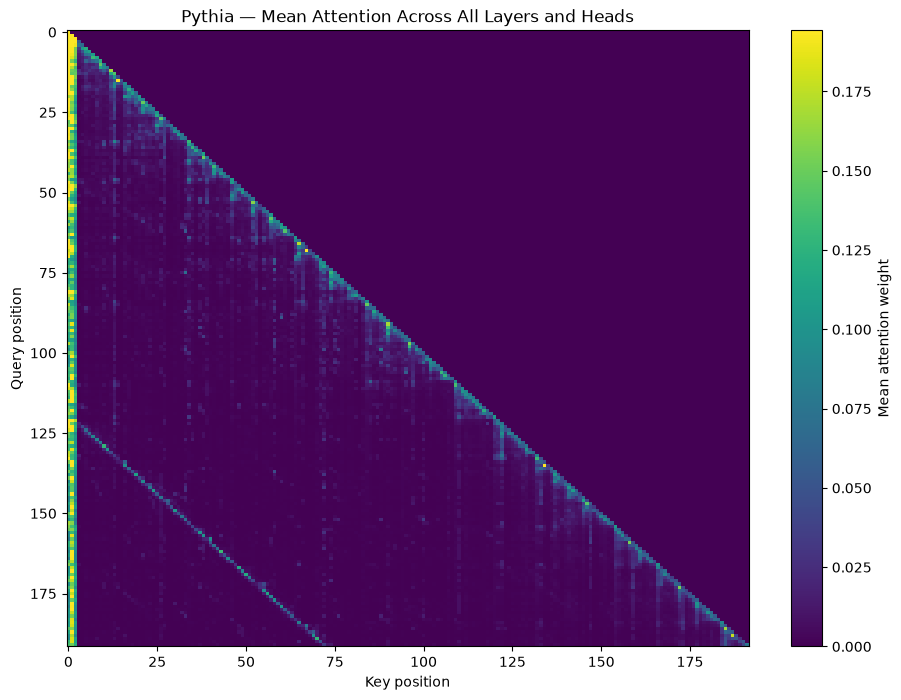

In [8]:
A_global = global_attention.numpy()

positive = A_global[A_global > 0]
vmax = np.percentile(positive, 99.5) if len(positive) else None

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(
    A_global,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=vmax,
)
fig.colorbar(im, ax=ax, label="Mean attention weight")
ax.set_xlabel("Key position")
ax.set_ylabel("Query position")
ax.set_title("Pythia — Mean Attention Across All Layers and Heads")
plt.show()

## 9. Attention received by each token

Raw cumulative attention:

\[
C_j = \sum_{i=j}^{T-1} A_{i,j}
\]

Because early positions are eligible to receive attention from more future queries, we also calculate:

\[
\bar{C}_j =
\frac{C_j}{T-j}
\]

The second quantity is much fairer for comparing early and late positions.

In [9]:
cumulative_attention = global_attention.sum(dim=0).numpy()

eligible_queries = np.arange(T, 0, -1, dtype=np.float64)
normalized_received = cumulative_attention / eligible_queries

token_df = pd.DataFrame({
    "position": np.arange(T),
    "token": tokens,
    "cumulative_attention": cumulative_attention,
    "mean_received_per_eligible_query": normalized_received,
})

display(
    token_df.sort_values(
        "mean_received_per_eligible_query",
        ascending=False
    ).head(20)
)

,position,token,cumulative_attention,mean_received_per_eligible_query
1,1,Ċ,32.875889,0.172125
0,0,<|endoftext|>,31.946627,0.166389
2,2,Ċ,21.100500,0.111055
191,191,",",0.075133,0.075133
185,185,ĠDuring,0.473136,0.067591
187,187,long,0.316560,0.063312
190,190,Ġinference,0.092093,0.046047
184,184,.,0.312502,0.039063
186,186,Ċ,0.213860,0.035643
177,177,Ġprevents,0.462016,0.030801


## 10. Better position plot: normalized attention received

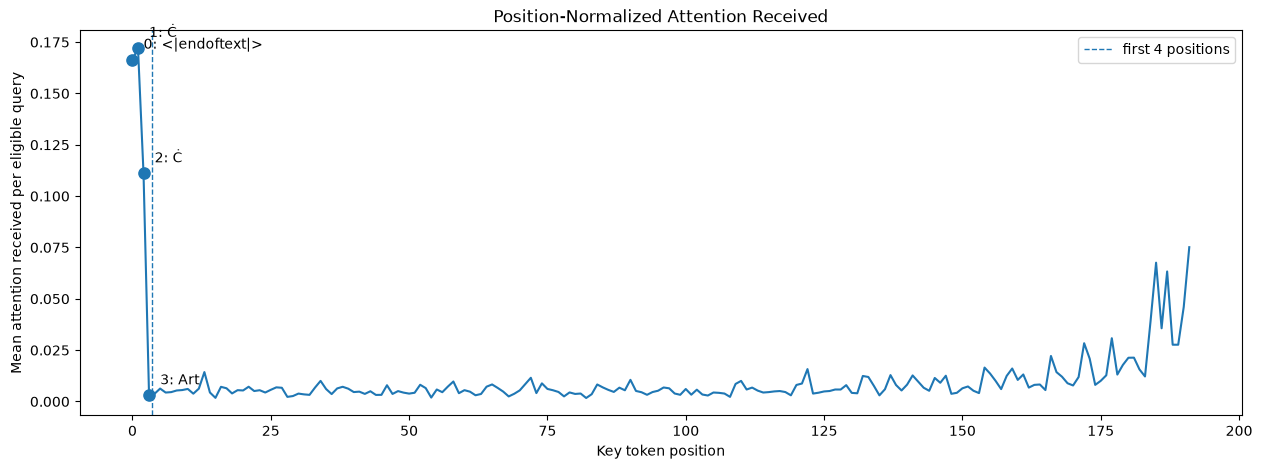

In [10]:
fig, ax = plt.subplots(figsize=(15, 5))

x = np.arange(T)
ax.plot(x, normalized_received, linewidth=1.5)
ax.scatter(x[:SINK_K], normalized_received[:SINK_K], s=65, zorder=3)

for i in range(min(SINK_K, T)):
    label = tokens[i].replace("Ġ", "▁")
    ax.annotate(
        f"{i}: {label}",
        (i, normalized_received[i]),
        xytext=(8, 8),
        textcoords="offset points",
    )

ax.axvline(
    SINK_K - 0.5,
    linestyle="--",
    linewidth=1,
    label=f"first {SINK_K} positions",
)

ax.set_xlabel("Key token position")
ax.set_ylabel("Mean attention received per eligible query")
ax.set_title("Position-Normalized Attention Received")
ax.legend()
plt.show()

## 11. Zoom into the first 32 positions

This makes early-position concentration much easier to inspect.

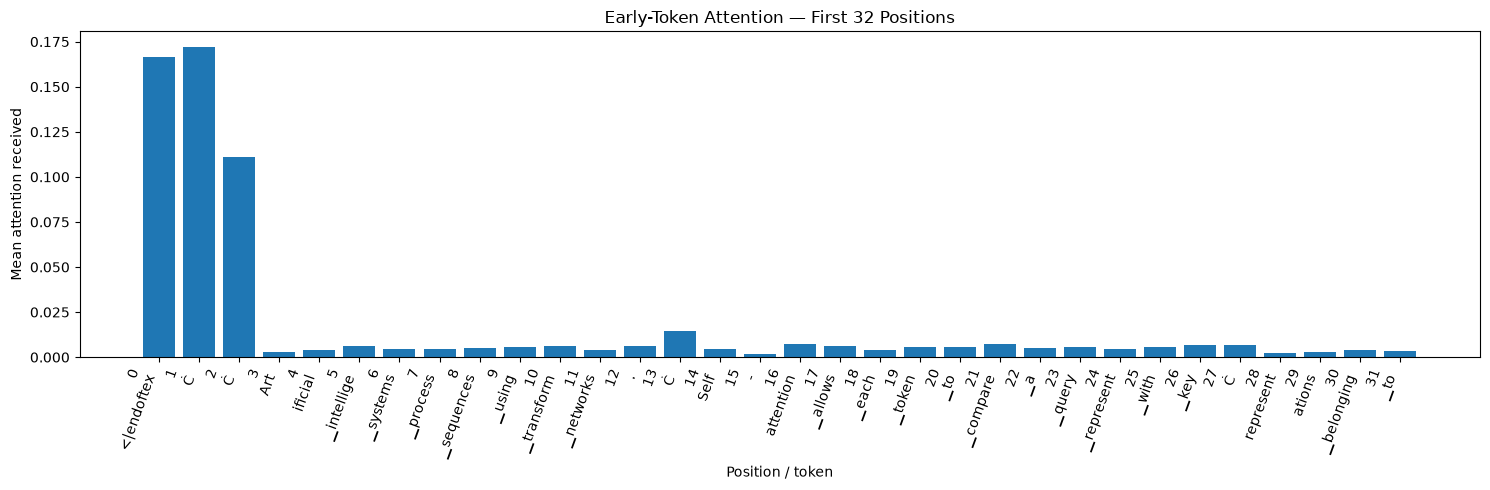

In [11]:
N = min(32, T)

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(np.arange(N), normalized_received[:N])

labels = [
    f"{i}\n{tokens[i].replace('Ġ', '▁')[:10]}"
    for i in range(N)
]

ax.set_xticks(np.arange(N))
ax.set_xticklabels(labels, rotation=70, ha="right")
ax.set_xlabel("Position / token")
ax.set_ylabel("Mean attention received")
ax.set_title(f"Early-Token Attention — First {N} Positions")
plt.tight_layout()
plt.show()

## 12. Define a per-head sink score

For each layer/head, measure the fraction of attention assigned to the first `SINK_K` positions, averaged over **later query positions**.

\[
S_{l,h}
=
\frac{1}{N}
\sum_{i \in \text{later queries}}
\sum_{j=0}^{K-1}
A^{(l,h)}_{i,j}
\]

We exclude the first few query positions themselves so that a head is rewarded for **later tokens continuing to attend backward to the sink region**.

In [12]:
query_start = max(SINK_K, 16)

# [layers, heads, later_queries, sink_keys]
sink_mass = attn_stack[:, :, query_start:, :SINK_K].sum(dim=-1)

# Average over later query positions.
sink_scores = sink_mass.mean(dim=-1)

assert torch.isfinite(sink_scores).all()

print("Sink score matrix shape:", tuple(sink_scores.shape))
print(
    f"Score = average fraction of attention sent to positions 0..{SINK_K-1} "
    f"from query positions {query_start}..{T-1}"
)

Sink score matrix shape: (12, 12)
Score = average fraction of attention sent to positions 0..3 from query positions 16..191


## 13. Layer × head sink-score heatmap

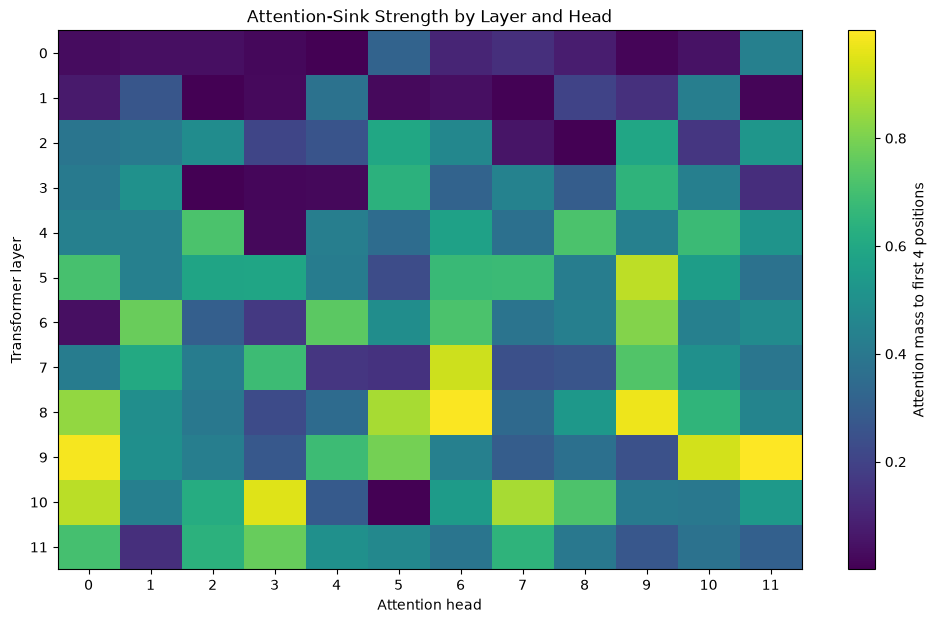

In [13]:
score_np = sink_scores.numpy()

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(score_np, aspect="auto", interpolation="nearest")
fig.colorbar(im, ax=ax, label=f"Attention mass to first {SINK_K} positions")

ax.set_xlabel("Attention head")
ax.set_ylabel("Transformer layer")
ax.set_title("Attention-Sink Strength by Layer and Head")
ax.set_xticks(np.arange(H))
ax.set_yticks(np.arange(L))
plt.show()

## 14. Rank the strongest sink heads

In [14]:
records = []

for layer_idx in range(L):
    for head_idx in range(H):
        A = attn_stack[layer_idx, head_idx]

        sink_score = A[query_start:, :SINK_K].sum(dim=-1).mean().item()
        token0_score = A[query_start:, 0].mean().item()

        records.append({
            "layer": layer_idx,
            "head": head_idx,
            f"mean_attention_to_first_{SINK_K}": sink_score,
            "mean_attention_to_position_0": token0_score,
        })

head_df = pd.DataFrame(records).sort_values(
    f"mean_attention_to_first_{SINK_K}",
    ascending=False,
).reset_index(drop=True)

display(head_df.head(20))

,layer,head,mean_attention_to_first_4,mean_attention_to_position_0
0,9,11,0.999688,0.237280
1,8,6,0.993345,0.048952
2,9,0,0.986553,0.065873
3,8,9,0.972545,0.078353
4,10,3,0.951894,0.649187
5,9,10,0.929637,0.229744
6,7,6,0.922109,0.091288
7,5,9,0.898351,0.180841
8,10,0,0.897864,0.637110
9,8,5,0.870299,0.144458


## 15. First-token attention by layer and head

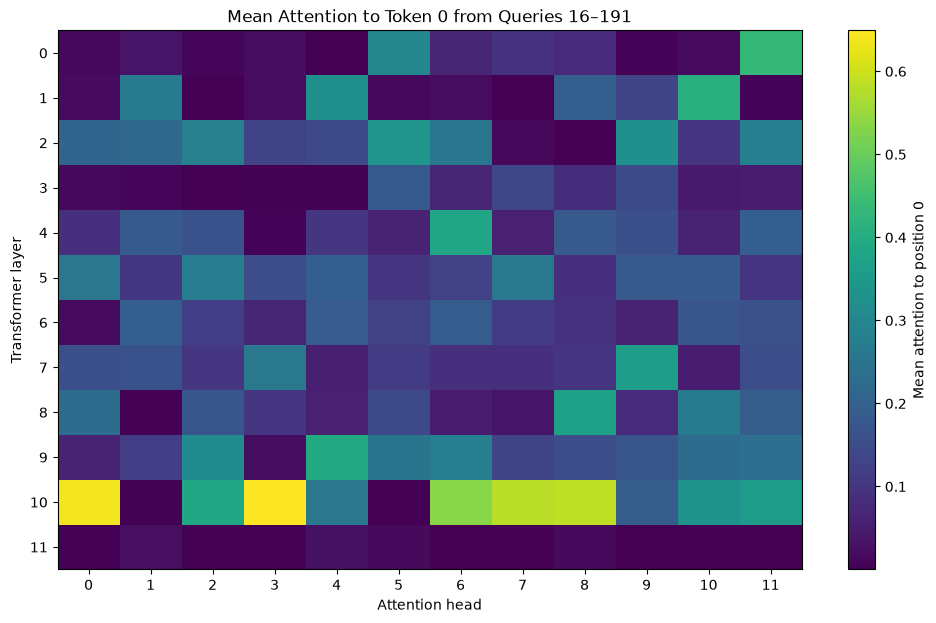

In [15]:
token0_scores = attn_stack[:, :, query_start:, 0].mean(dim=2).numpy()

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(token0_scores, aspect="auto", interpolation="nearest")
fig.colorbar(im, ax=ax, label="Mean attention to position 0")

ax.set_xlabel("Attention head")
ax.set_ylabel("Transformer layer")
ax.set_title(
    f"Mean Attention to Token 0 from Queries {query_start}–{T-1}"
)
ax.set_xticks(np.arange(H))
ax.set_yticks(np.arange(L))
plt.show()

## 16. Strongest sink head

Automatically select the layer/head with the largest first-`K` sink-region score.

In [16]:
best = head_df.iloc[0]

best_layer = int(best["layer"])
best_head = int(best["head"])

A_best = attn_stack[best_layer, best_head].numpy()

print("Strongest sink head")
print("-------------------")
print("Layer:", best_layer)
print("Head:", best_head)
print(
    f"Mean attention to first {SINK_K} positions:",
    f"{best[f'mean_attention_to_first_{SINK_K}']:.4f}"
)
print(
    "Mean attention to position 0:",
    f"{best['mean_attention_to_position_0']:.4f}"
)

Strongest sink head
-------------------
Layer: 9
Head: 11
Mean attention to first 4 positions: 0.9997
Mean attention to position 0: 0.2373


## 17. Heatmap of the strongest sink head

The first few columns are the early key positions.

A visible vertical band near the left edge indicates that many later query positions repeatedly attend to the same early token(s).

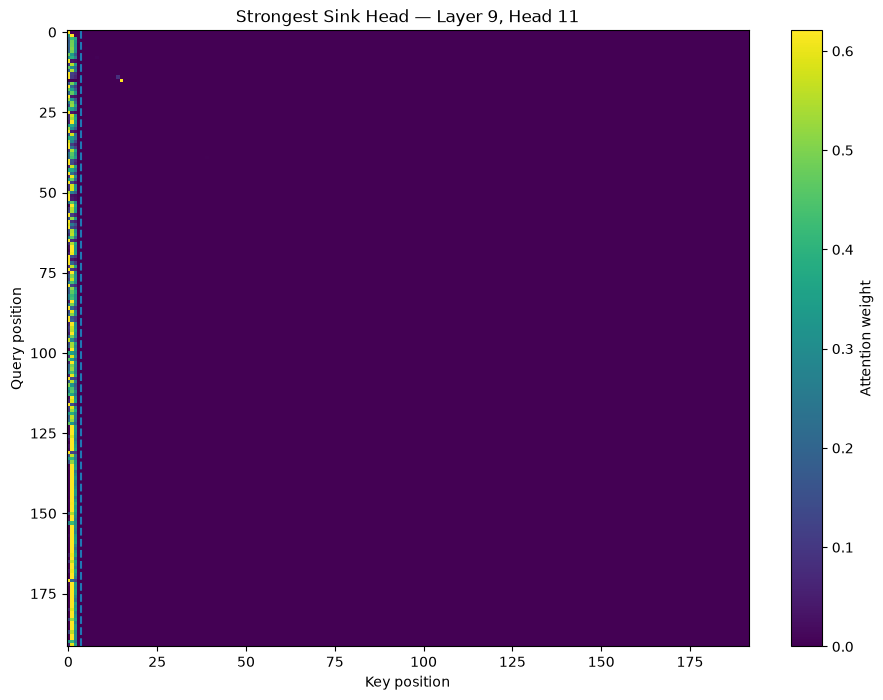

In [17]:
positive = A_best[A_best > 0]
vmax = np.percentile(positive, 99.5) if len(positive) else None

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(
    A_best,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=vmax,
)
fig.colorbar(im, ax=ax, label="Attention weight")

ax.axvline(
    SINK_K - 0.5,
    linestyle="--",
    linewidth=1.5,
)

ax.set_xlabel("Key position")
ax.set_ylabel("Query position")
ax.set_title(
    f"Strongest Sink Head — Layer {best_layer}, Head {best_head}"
)
plt.show()

## 18. How strongly does each later query attend to the sink?

This is one of the clearest sink visualizations.

For every query position, we plot:

- attention to position 0
- total attention to the first `K` positions

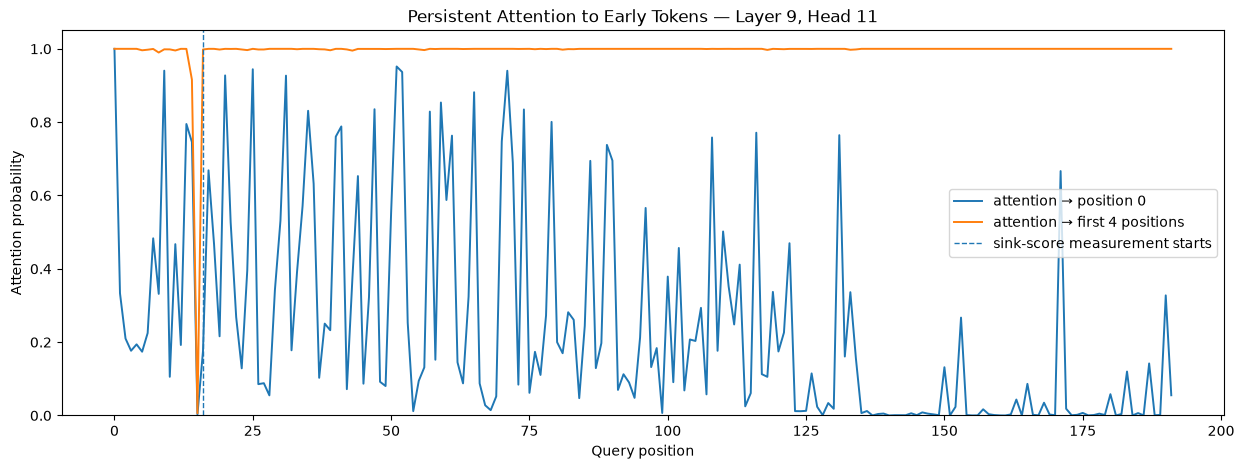

In [18]:
to_token0 = A_best[:, 0]
to_sink_region = A_best[:, :SINK_K].sum(axis=1)

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    np.arange(T),
    to_token0,
    label="attention → position 0",
    linewidth=1.4,
)

ax.plot(
    np.arange(T),
    to_sink_region,
    label=f"attention → first {SINK_K} positions",
    linewidth=1.4,
)

ax.axvline(
    query_start,
    linestyle="--",
    linewidth=1,
    label="sink-score measurement starts",
)

ax.set_xlabel("Query position")
ax.set_ylabel("Attention probability")
ax.set_ylim(bottom=0)
ax.set_title(
    f"Persistent Attention to Early Tokens — Layer {best_layer}, Head {best_head}"
)
ax.legend()
plt.show()

## 19. Cumulative attention for the strongest head

This tells us which key positions receive the most total attention from the sequence.

In [20]:
received_best = A_best.sum(axis=0)
top_n = min(20, T)
top_idx = np.argsort(received_best)[::-1][:top_n]

top_df = pd.DataFrame({
    "rank": np.arange(1, top_n + 1),
    "position": top_idx,
    "token": [tokens[i] for i in top_idx],
    "total_attention_received": received_best[top_idx],
})

display(top_df)

,rank,position,token,total_attention_received
0,1,1,Ċ,93.289124
1,2,2,Ċ,49.404999
2,3,0,<|endoftext|>,48.138004
3,4,15,-,0.993218
4,5,14,Self,0.083752
5,6,5,Ġintelligence,0.016273
6,7,8,Ġsequences,0.014040
7,8,6,Ġsystems,0.012405
8,9,3,Art,0.010621
9,10,39,Ċ,0.007519


## 20. Bar chart of the top-attended positions

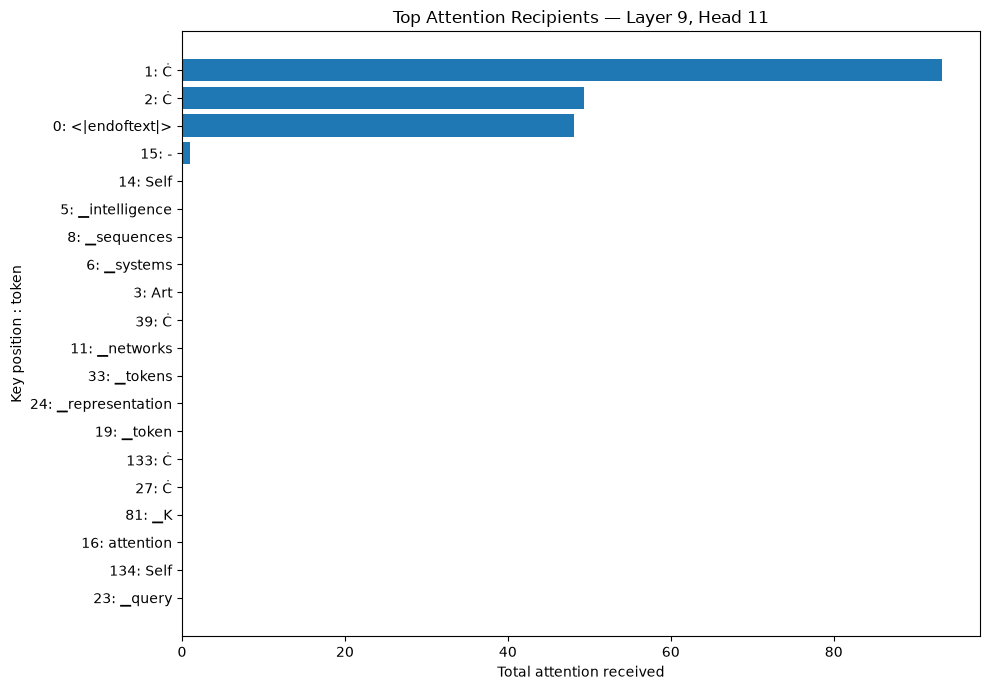

In [21]:
plot_df = top_df.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 7))

labels = [
    f"{int(pos)}: {tok.replace('Ġ', '▁')[:18]}"
    for pos, tok in zip(plot_df["position"], plot_df["token"])
]

ax.barh(
    np.arange(len(plot_df)),
    plot_df["total_attention_received"],
)

ax.set_yticks(np.arange(len(plot_df)))
ax.set_yticklabels(labels)
ax.set_xlabel("Total attention received")
ax.set_ylabel("Key position : token")
ax.set_title(
    f"Top Attention Recipients — Layer {best_layer}, Head {best_head}"
)

plt.tight_layout()
plt.show()

## 21. Layer-level sink strength

Average the sink score over all heads in each transformer layer.

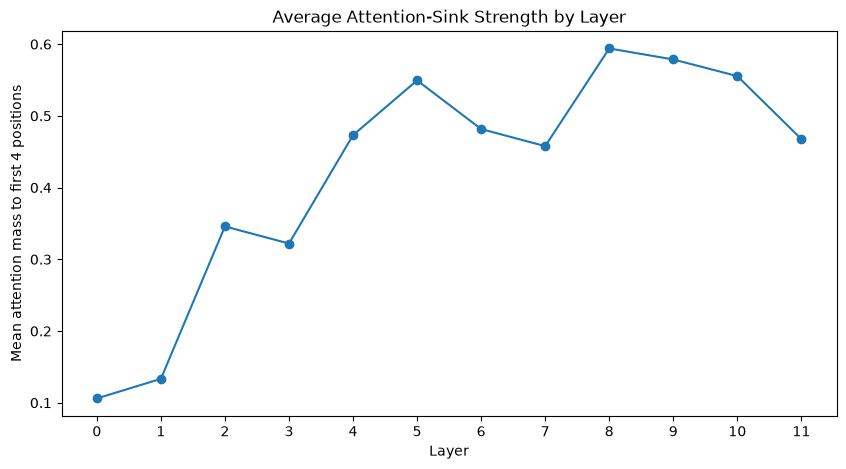

In [22]:
layer_sink_scores = sink_scores.mean(dim=1).numpy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    np.arange(L),
    layer_sink_scores,
    marker="o",
)

ax.set_xticks(np.arange(L))
ax.set_xlabel("Layer")
ax.set_ylabel(f"Mean attention mass to first {SINK_K} positions")
ax.set_title("Average Attention-Sink Strength by Layer")
plt.show()

## 22. Inspect the first tokens numerically

In [23]:
display(
    token_df.iloc[:20][
        [
            "position",
            "token",
            "cumulative_attention",
            "mean_received_per_eligible_query",
        ]
    ]
)

,position,token,cumulative_attention,mean_received_per_eligible_query
0,0,<|endoftext|>,31.946627,0.166389
1,1,Ċ,32.875889,0.172125
2,2,Ċ,21.100500,0.111055
3,3,Art,0.556072,0.002942
4,4,ificial,0.710220,0.003778
5,5,Ġintelligence,1.176902,0.006294
6,6,Ġsystems,0.809983,0.004355
7,7,Ġprocess,0.844392,0.004564
8,8,Ġsequences,0.986734,0.005363
9,9,Ġusing,1.018419,0.005565


## 23. Simple sink summary

This compares normalized attention received by the first `K` positions with a central part of the sequence.

In [24]:
early_mean = normalized_received[:SINK_K].mean()

middle_start = T // 3
middle_end = 2 * T // 3
middle_mean = normalized_received[middle_start:middle_end].mean()

sink_ratio = early_mean / max(middle_mean, 1e-12)

print(f"First {SINK_K} positions mean normalized attention : {early_mean:.6f}")
print(f"Middle-region mean normalized attention           : {middle_mean:.6f}")
print(f"Early / middle ratio                              : {sink_ratio:.2f}x")

if sink_ratio > 2:
    print("\nStrong early-position concentration is visible.")
elif sink_ratio > 1.25:
    print("\nModerate early-position concentration is visible.")
else:
    print("\nWeak global early-position concentration for this prompt/model.")
    print("Inspect the head-level plots: sinks may be concentrated in specific heads.")

First 4 positions mean normalized attention : 0.113128
Middle-region mean normalized attention           : 0.005537
Early / middle ratio                              : 20.43x

Strong early-position concentration is visible.
